# Reading and Analyzing GRMONTY Spectral Energy Distributions

This notebook demonstrates how to read, process, and analyze spectral energy distribution (SED) outputs produced by **GPUmonty** simulations.

The main goals of this example are:
- To load GPUmonty `.spec` files using `astropy.io.ascii`
- To convert the tabulated quantities into physical units
- To reconstruct the spectral luminosity \( \nu L_\nu \) for multiple viewing angles

## Initialization

In [5]:
import numpy as np
from astropy.io import ascii
import matplotlib.pyplot as plt

Important constants

In [4]:
LSUN = 3.827e33
CL = 2.99792458e10
ME = 9.1093826e-28
HPL =  6.6260693e-27

## Helper function

The cell below defines a helper function, `grmonty(file)`, which:
1. Reads a GRMONTY SED file with no header.
2. Extracts frequency bins and converts them to physical frequencies.
3. Builds arrays of luminosities for six viewing angles, converting from solar luminosities to cgs units.
5. Returns the frequency array and luminosity arrays for plotting

The notebook also defines the solid-angle weights (`domega_array`) associated with each of the six angular bins, which are typically used when computing angle-averaged spectra.

This setup provides a minimal, reproducible example for inspecting GRMONTY outputs and serves as a starting point for plotting spectra, comparing runs, or integrating over angles.

In [6]:
def grmonty(file):
    """
    Reads SEDs in the format provided by grmonty.
    
    Returns:
        nu: Frequency array
        ll: Luminosity array (log10)
        tauabs: Absorption optical depth
        domega: Array of solid angles for each theta bin
    """
    domega_arr = None
    with open(file, 'r') as f:
        for line in f:
            if line.startswith("# dOmega:"):
                # Split by colon to get the numbers, then split by space
                parts = line.split(':')[1].strip().split()
                domega_arr = np.array([np.float64(x) for x in parts])
                break
    
    if domega_arr is None:
        print(f"Warning: No dOmega header found in {file}")

    s = ascii.read(file, format='no_header')

    ll = np.zeros((6, len(s))) 
    ll[0] = np.array(s['col2'] * LSUN)
    ll[1] = np.array(s['col8'] * LSUN)
    ll[2] = np.array(s['col14']* LSUN)
    ll[3] = np.array(s['col20']* LSUN)
    ll[4] = np.array(s['col26']* LSUN)
    ll[5] = np.array(s['col32']* LSUN)
    
    tauabs = np.zeros((6, len(s)))
    tauabs[0] = np.array(s['col3'])     
    tauabs[1] = np.array(s['col9'])
    tauabs[2] = np.array(s['col15'])
    tauabs[3] = np.array(s['col21'])
    tauabs[4] = np.array(s['col27'])
    tauabs[5] = np.array(s['col33'])

    nu = np.array(10**s['col1'] * (ME * CL**2/HPL))

    return nu, ll, tauabs, domega_arr

nu, nuLnu, tauabs, domega_array = grmonty('../output/sphere_scattering_1e8.spec')

In [7]:
import h5py

# Open the HDF5 file
with h5py.File('../output/spectrum_scattering_igrmonty_1e8.h5', 'r') as f:
#with h5py.File('../../igrmonty/spectrum.h5', 'r') as f:
    # Access the 'output' group
    output_group = f['output']
    LSUN = 3.827e33
    # Extract the datasets 'lnu' and 'nulnu'
    nu_igr = 10**output_group['lnu'][:] * (ME * CL**2/HPL)
    nuLnu_igr = output_group['nuLnu'][:] * LSUN
    dOmega_igr = output_group['dOmega'][:]

In [8]:
nu1e5, nuLnu1e5, tauabs, domega_array = grmonty('../output/sphere_scattering_1e5.spec')
nu1e6, nuLnu1e6, tauabs, domega_array = grmonty('../output/sphere_scattering_1e6.spec')
nu1e7, nuLnu1e7, tauabs, domega_array = grmonty('../output/sphere_scattering_1e7.spec')
nu1e8, nuLnu1e8, tauabs, domega_array = grmonty('../output/sphere_scattering_1e8.spec')

## Plots

In [9]:
def moving_average(y, n=10):
    """
    Sliding window average with ±n neighbors (window = 2n+1)
    """
    kernel = np.ones(2*n + 1) / (2*n + 1)
    return np.convolve(y, kernel, mode='same')

/tmp/ipykernel_719934/4014818232.py:46: RuntimeWarning: invalid value encountered in divide
  diff_1e5 = np.abs(y_simdata_1e5 - y_igr_interp) / y_igr_interp
/tmp/ipykernel_719934/4014818232.py:47: RuntimeWarning: invalid value encountered in divide
  diff_1e6 = np.abs(y_simdata_1e6 - y_igr_interp) / y_igr_interp
/tmp/ipykernel_719934/4014818232.py:48: RuntimeWarning: divide by zero encountered in divide
  diff_1e7 = np.abs(y_simdata_1e7 - y_igr_interp) / y_igr_interp
/tmp/ipykernel_719934/4014818232.py:48: RuntimeWarning: invalid value encountered in divide
  diff_1e7 = np.abs(y_simdata_1e7 - y_igr_interp) / y_igr_interp
/tmp/ipykernel_719934/4014818232.py:49: RuntimeWarning: divide by zero encountered in divide
  diff_1e8 = np.abs(y_simdata_1e8 - y_igr_interp) / y_igr_interp
/tmp/ipykernel_719934/4014818232.py:49: RuntimeWarning: invalid value encountered in divide
  diff_1e8 = np.abs(y_simdata_1e8 - y_igr_interp) / y_igr_interp
/tmp/ipykernel_719934/4014818232.py:93: UserWarning: Thi

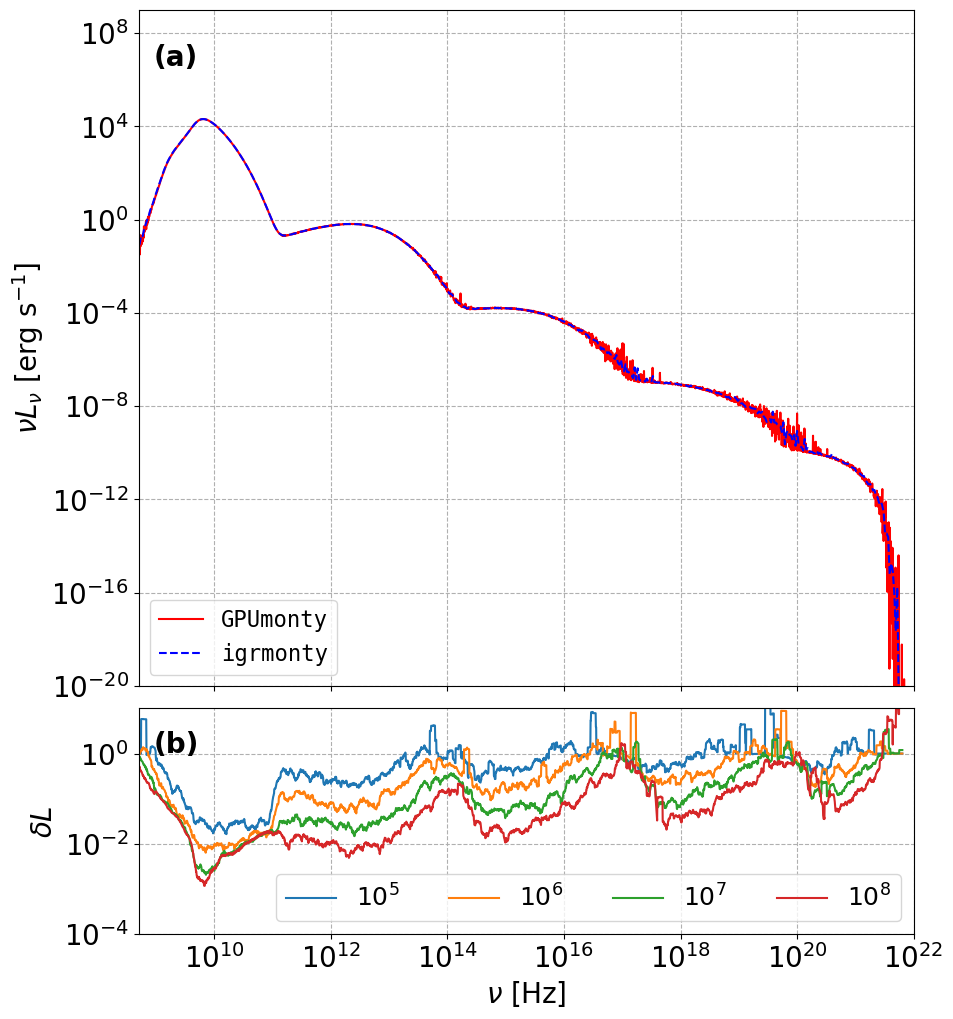

In [10]:
# --- Create figure with gridspec (2 panels only) ---
fig = plt.figure(figsize=(10, 12))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
fs = 16
y_igr = (nuLnu_igr.sum(0) * dOmega_igr / (4 * np.pi)).sum(1)
# -------------------------
# (a) Top panel: spectra
# -------------------------
ax1 = fig.add_subplot(gs[0, 0])
y_simdata = (nuLnu* domega_array[:,None]/(4* np.pi)).sum(0)
ax1.plot(nu, y_simdata, linestyle='-', color='red',
         label="GPUmonty")
ax1.plot(nu_igr, y_igr, linestyle='--', color='blue',
         label="igrmonty")

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel(r"$\nu L_\nu$ [erg s$^{-1}$]", fontsize=20)

ax1.set_ylim(1e-20, 1e9)
ax1.set_xlim(1e9, 1e24)

ax1.grid(True, which="both", ls="--")
ax1.tick_params(axis='both', which='both', labelsize=20)

legend_font = {'family': 'monospace', 'size': fs}
ax1.legend(prop=legend_font, loc='lower left', fontsize = 20)

# Panel label
ax1.text(0.02, 0.95, r"(a)",
         transform=ax1.transAxes,
         fontsize=20, fontweight = 'bold', va='top')

# --------------------------------
# (b) Middle panel: relative error
# --------------------------------
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)

y_igr_interp = np.interp(nu, nu_igr, y_igr)

y_simdata_1e5 = (nuLnu1e5 * domega_array[:, None] / (4 * np.pi)).sum(0)
y_simdata_1e6 = (nuLnu1e6 * domega_array[:, None] / (4 * np.pi)).sum(0)
y_simdata_1e7 = (nuLnu1e7 * domega_array[:, None] / (4 * np.pi)).sum(0)
y_simdata_1e8 = (nuLnu1e8 * domega_array[:, None] / (4 * np.pi)).sum(0)

diff_1e5 = np.abs(y_simdata_1e5 - y_igr_interp) / y_igr_interp
diff_1e6 = np.abs(y_simdata_1e6 - y_igr_interp) / y_igr_interp
diff_1e7 = np.abs(y_simdata_1e7 - y_igr_interp) / y_igr_interp
diff_1e8 = np.abs(y_simdata_1e8 - y_igr_interp) / y_igr_interp

# Window-averaged (±10 neighbors)
nwin = 10
diff_1e5_avg = moving_average(diff_1e5, nwin)
diff_1e6_avg = moving_average(diff_1e6, nwin)
diff_1e7_avg = moving_average(diff_1e7, nwin)
diff_1e8_avg = moving_average(diff_1e8, nwin)


ax2.plot(nu, diff_1e5_avg, label=r"$10^5$")
ax2.plot(nu, diff_1e6_avg, label=r"$10^6$")
ax2.plot(nu, diff_1e7_avg, label=r"$10^7$")
ax2.plot(nu, diff_1e8_avg, label=r"$10^8$")

ax2.set_xscale('log')
ax2.set_yscale('log')

ax2.set_xlabel(r"$\nu$ [Hz]", fontsize=20)
ax2.set_ylabel(
    r"$\delta L$",
    fontsize=20
)

ax2.set_ylim(1e-4, 1e1)
ax2.set_xlim(5e8, 1e22)
ax2.grid(True, which="both", ls="--")
ax2.tick_params(axis='both', which='both', labelsize=20)
ax2.legend(
    fontsize=18,
    loc='lower right',
    bbox_to_anchor=(1.0, 0.0),
    frameon=True,
    ncol = 4
)

# Panel label
ax2.text(0.02, 0.90, r"(b)",
         transform=ax2.transAxes,
         fontsize=20, fontweight = 'bold', va='top')

# Remove x tick labels from top panel
plt.setp(ax1.get_xticklabels(), visible=False)

plt.tight_layout()
#plt.savefig("spectra_comparison_ab.png", dpi=300)
plt.show()

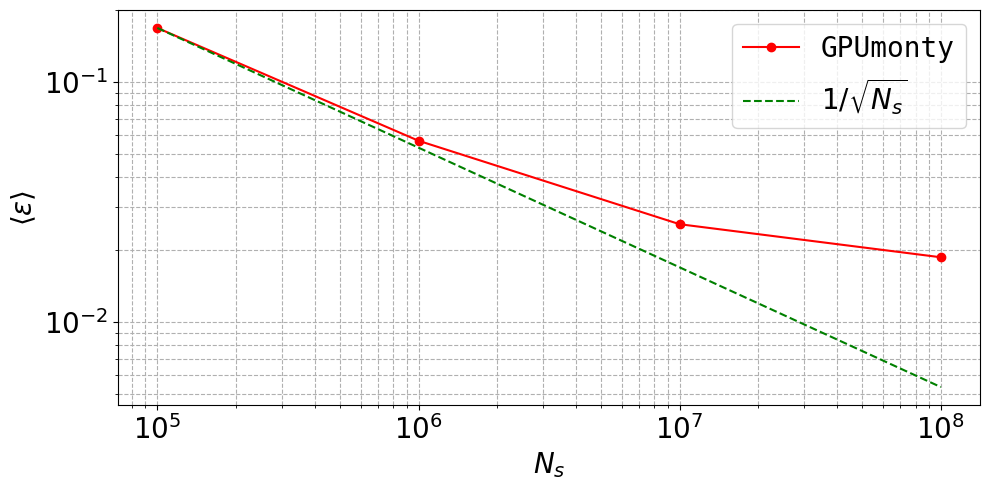

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
nu1e5, nuLnu1e5, _, _ = grmonty('../output/sphere_scattering_1e5.spec')
nu1e6, nuLnu1e6, _, _ = grmonty('../output/sphere_scattering_1e6.spec')
nu1e7, nuLnu1e7, _ , _= grmonty('../output/sphere_scattering_1e7.spec')
nu1e8, nuLnu1e8, _ , _= grmonty('../output/sphere_scattering_1e8.spec')

nu = nu1e7

# igrmonty spectrum
y_igr = (nuLnu_igr.sum(0) * dOmega_igr / (4 * np.pi)).sum(1)
y_igr_interp = np.interp(nu, nu_igr, y_igr)

# Frequency limits for averaging
numin = 1e9
numax = 1e12
mask = (nu >= numin) & (nu <= numax)
nu_masked = nu[mask]

# -----------------------------
# Compute <epsilon>
# -----------------------------
Ns_array = np.array([1e5, 1e6, 1e7, 1e8])
y_list = [nuLnu1e5, nuLnu1e6, nuLnu1e7, nuLnu1e8]

epsilon_avg_list = []

for y_sim in y_list:
    y_simdata = (y_sim * domega_array[:, None] / (4 * np.pi)).sum(0)

    y_sim_masked = y_simdata[mask]
    y_igr_masked = y_igr_interp[mask]

    frac_error = np.abs(y_sim_masked - y_igr_masked) / y_igr_masked

    dlnnu = np.log(nu_masked[1:] / nu_masked[:-1])
    epsilon_avg = np.sum(frac_error[1:] * dlnnu) / np.log(numax / numin)

    epsilon_avg_list.append(epsilon_avg)

epsilon_avg_list = np.array(epsilon_avg_list)

# -----------------------------
# Plot panel (c)
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))

# GPUmonty curve
ax.plot(
    Ns_array,
    epsilon_avg_list,
    'o-',
    color='red',
    label='GPUmonty'
)

# Reference scaling
ax.plot(
    Ns_array,
    epsilon_avg_list[0] * (Ns_array[0] / Ns_array)**0.5,
    '--',
    color='green',
    label=r'$1/\sqrt{N_s}$'
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r"$N_s$", fontsize=20)
ax.set_ylabel(r"$\langle \epsilon \rangle$", fontsize=20)

ax.grid(True, which="both", ls="--")

# Major + minor ticks
ax.tick_params(axis='both', which='major', labelsize=20)
ax.tick_params(axis='both', which='minor', labelsize=20)

# Legend
leg = ax.legend(fontsize=20)

# Make only "GPUmonty" monospace
for text in leg.get_texts():
    if text.get_text() == 'GPUmonty':
        text.set_fontfamily('monospace')

plt.tight_layout()
#plt.savefig("panel_c_convergence.png", dpi=300)
plt.show()